In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:

# import os
# print(os.listdir())
import pandas as pd
# time was not available ,so added time
df = pd.read_csv("data/creditcard_2023.csv")
# df1 = pd.read_csv("data/creditcard (1).csv")
# df["Time"] = 0

# Time ko first column banana hai
# cols = ["Time"] + [col for col in df.columns if col != "Time"]
# df = df[cols]
# df.to_csv("data/creditcard_2023.csv", index=False)

print(df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -0.091643 -0.344923  1.219756 -0.791952  1.137763  0.842277  0.666837   
1     0  0.992508  0.477113 -0.791211  1.094632  1.031308 -0.932714  0.190378   
2     0  0.552787 -0.296332  0.766482 -0.554333  0.247203  0.242513  0.451522   
3     0  1.733992 -0.161984 -0.015707  0.649146  0.872853  0.396859  0.696166   
4     0 -0.033540 -0.706702  1.481000 -1.651385 -0.228774  0.389222  0.084205   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0 -0.113052  0.242823  ... -0.183742 -0.655857 -0.357299 -2.738323  0.994943   
1 -0.126180 -0.852698  ... -0.061848 -0.776313 -0.065391  0.721947  0.560954   
2 -0.147877  0.857426  ... -0.077359  0.278519 -0.255873 -0.565539  0.701175   
3 -0.228645  0.448475  ... -0.121396  0.121199  0.002385  1.159917  0.609435   
4 -0.106864 -0.231745  ... -0.122349  0.477585  0.277132 -0.131301 -1.626834   

        V26       V27       V28 

In [4]:
import pandas as pd
df1 = pd.read_csv("data/creditcard.csv")
# df1 = df1.drop("Class",axis=1)
print(df1.head())
df1.to_csv("data/creditcard_2013.csv",index=False);

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27 

In [5]:
!pip install imbalanced-learn scikit-learn seaborn matplotlib


In [6]:
print("Shape: ",df.shape)

Shape:  (40000, 31)


In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df['Class'].value_counts()


Class
0.0    29154
1.0    10846
Name: count, dtype: int64

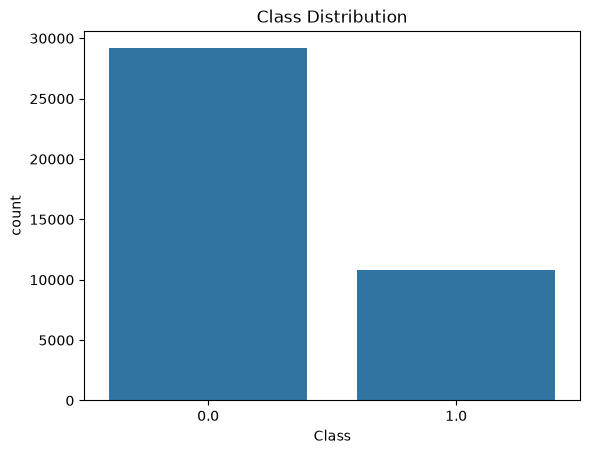

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
# shows the data is how much imbalanced
sns.countplot(x='Class',data = df)
plt.title("Class Distribution")
plt.show()

In [10]:
X = df.drop("Class",axis=1)
y = df["Class"]

print(X.shape)
print(y.shape)

(40000, 30)
(40000,)


In [11]:
import joblib
from sklearn.model_selection import train_test_split

X_train, X_test, y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
print("Train:",X_train.shape)
print("Test:",X_test.shape)

# Save train/test splits
# joblib.dump(X_train, "X_train.pkl")
# joblib.dump(X_test, "model/X_test.pkl")
# joblib.dump(y_train, "y_train.pkl")
# joblib.dump(y_test, "model/y_test.pkl")

Train: (32000, 30)
Test: (8000, 30)


In [12]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state = 42)

X_train_res, y_train_res = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter Smote:")
print(y_train_res.value_counts())

Before SMOTE:
Class
0.0    23323
1.0     8677
Name: count, dtype: int64

After Smote:
Class
1.0    23323
0.0    23323
Name: count, dtype: int64


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)

rf.fit(X_train_res, y_train_res)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [14]:
y_pred = rf.predict(X_test)

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))
# For fraud detection:

    # Precision = 0.99
    # When the model says "Fraud", it is correct 99% of the time.
    # Recall = 0.99
    # It catches 99% of actual fraud transactions.
    # Misses about 1%.

    # Recall is usually the most important metric in fraud detection because missing fraud costs money


              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      5831
         1.0       0.99      0.99      0.99      2169

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000



In [16]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred)

print(cm_rf)

[[5819   12]
 [  32 2137]]


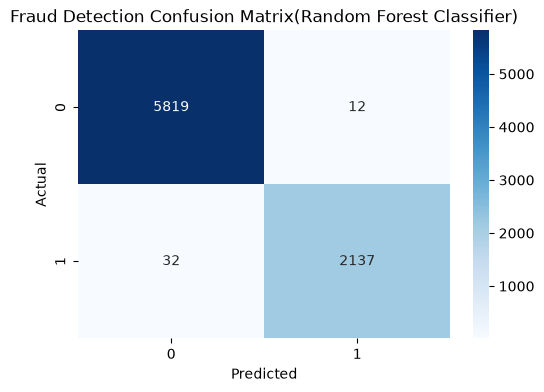

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Fraud Detection Confusion Matrix(Random Forest Classifier)")
plt.show()

In [18]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score: ",auc)
# Anything above:

    # 0.90 → Excellent
    # 0.95 → Outstanding
    # 0.99 → Production-level

ROC-AUC Score:  0.9998695783391405


In [19]:
import joblib

joblib.dump(rf,"model/random_forest/model.pkl")

['model/random_forest/model.pkl']

In [20]:
!pip install xgboost

In [21]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators = 100,
    max_depth = 6,
    learning_rate = 0.1,
    random_state = 42,
    eval_metric = 'logloss'
)

xgb.fit(X_train_res, y_train_res)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [22]:
y_pred_xgb = xgb.predict(X_test)

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

# For fraud detection:

    # Precision = 1.00
    # When the model says "Fraud", it is correct 100% of the time.
    # Recall = 0.99
    # It catches 99% of actual fraud transactions.
    # Misses about 1%.

    # Recall is usually the most important metric in fraud detection because missing fraud costs money.

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5831
         1.0       0.99      0.99      0.99      2169

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000



In [24]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob_xgb)

print("ROC-AUC:", auc)
# Anything above:

    # 0.90 → Excellent
    # 0.95 → Outstanding
    # 0.99 → Production-level

ROC-AUC: 0.9997176898817223


In [25]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

[[5804   27]
 [  29 2140]]


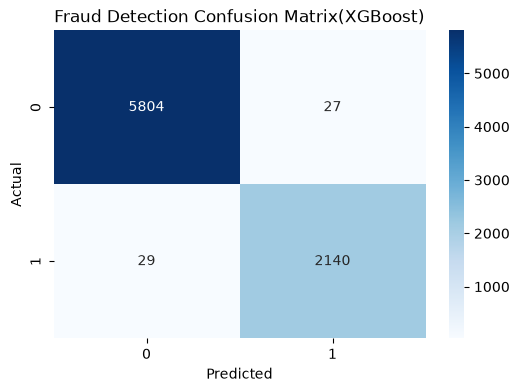

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Fraud Detection Confusion Matrix(XGBoost)")
plt.show()

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

In [28]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

In [29]:
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

xgb_metrics = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1 Score": f1_score(y_test, xgb_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob)
}

In [30]:
results = pd.DataFrame([rf_metrics, xgb_metrics])
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9945,0.994416,0.985247,0.989810,0.999870
1,XGBoost,0.9930,0.987540,0.986630,0.987085,0.999718


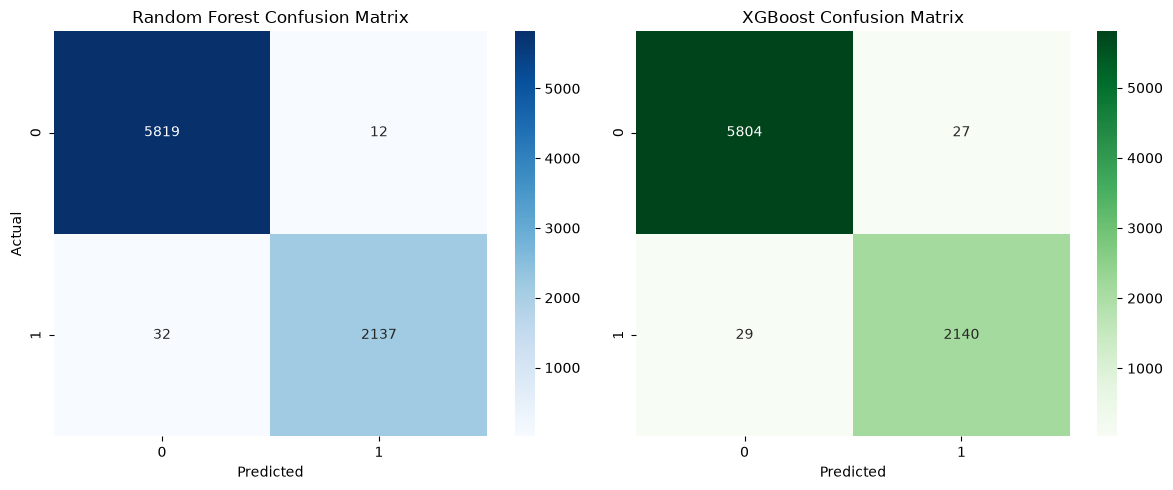

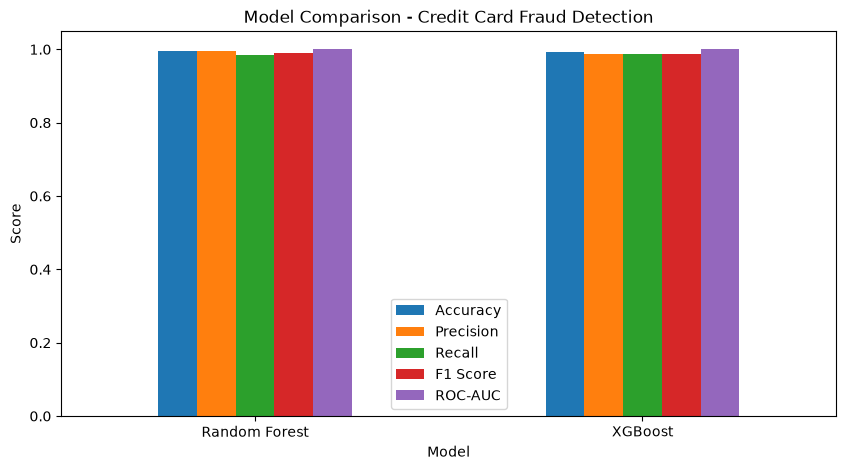

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Random Forest Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("XGBoost Confusion Matrix")
ax[1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()
results.set_index("Model").plot(kind="bar", figsize=(10,5))
plt.title("Model Comparison - Credit Card Fraud Detection")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

   Feature  Importance
14     V14    0.675104
4       V4    0.050945
12     V12    0.029501
10     V10    0.025182
1       V1    0.020273
3       V3    0.019113
11     V11    0.013080
9       V9    0.012280
17     V17    0.011632
25     V25    0.011092


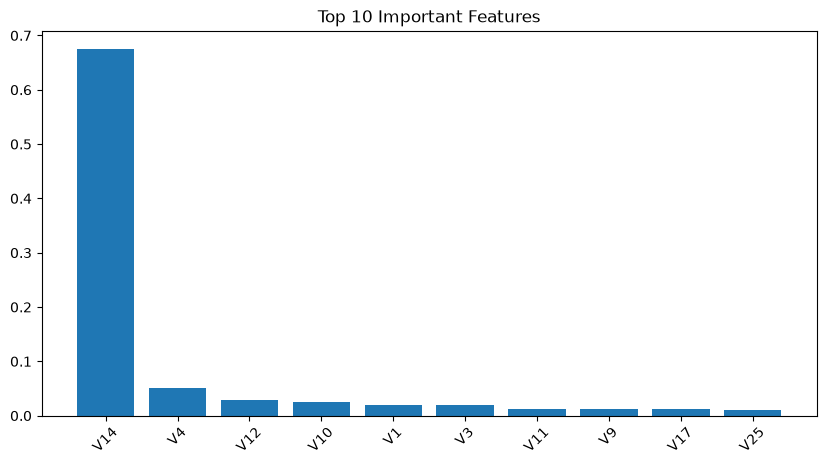

In [33]:
top10 = importance.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Feature'], top10['Importance'])
plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.show()

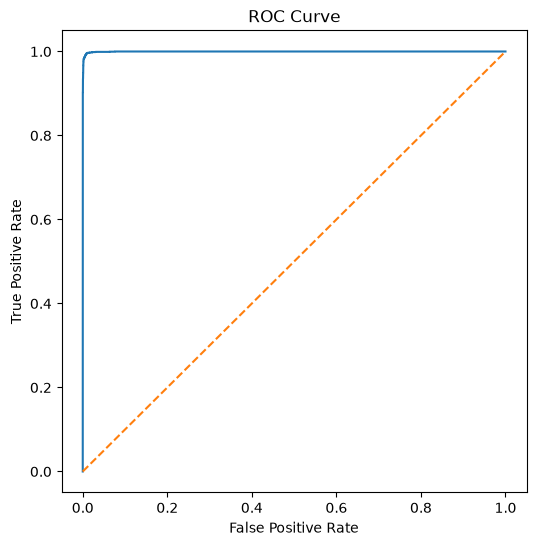

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [35]:
import joblib

joblib.dump(xgb, "model/xgboost/model.pkl")

['model/xgboost/model.pkl']